Let's make a EDA with our data. We have to have a clear data to make a great a prediction model.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [2]:
data=pd.read_csv("/content/drive/MyDrive/Mu_files/Loan_Default.csv")
data.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


We have deleted two colums of our dataset. Because they are useless and can't affect our model



In [3]:
data=data.drop(["ID","year"],axis=1)

I want to figure out some knowledge about two features. Are they useless?

In [4]:
data['Region'].unique()

array(['south', 'North', 'central', 'North-East'], dtype=object)

I also want to analyze the dependence between the Region feature and the target variable Status to see if there is any significant pattern or correlation.

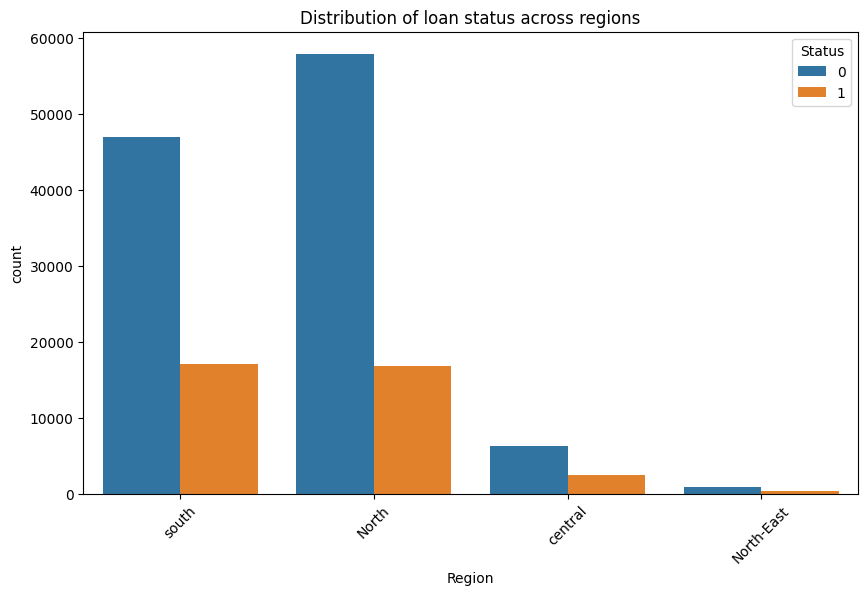

In [5]:
plt.figure(figsize=(10, 6))
sns.countplot(data, x='Region', hue='Status')
plt.xticks(rotation=45)
plt.title('Distribution of loan status across regions')
plt.show()

This fragment of code shows the balance between the target classes.

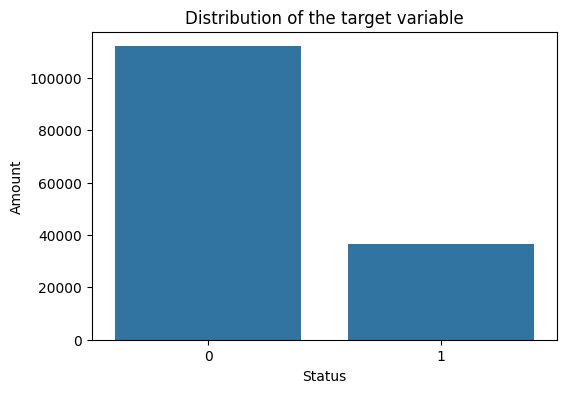

In [6]:
plt.figure(figsize=(6, 4))
sns.countplot(x=data['Status'])
plt.title('Distribution of the target variable')
plt.xlabel('Status')
plt.ylabel('Amount')
plt.show()

Let's work with Nan values

In [7]:
data.isna().sum()

,0
loan_limit,3344
Gender,0
approv_in_adv,908
loan_type,0
loan_purpose,134
Credit_Worthiness,0
open_credit,0
business_or_commercial,0
loan_amount,0
rate_of_interest,36439


I will drop rows containing NaN values if their number is below 200.I think it cant effect our model

In [8]:
data=data.dropna(subset=['age','submission_of_application','loan_purpose','term','Neg_ammortization'])

And fill the remaining rows with their mode. This will help the model be more robust to outliers.

In [9]:
object_data=data.select_dtypes(include=['object']).columns
for col in object_data:
    data[col]=data[col].fillna(data[col].mode()[0])

In [10]:
numeric_data = data.select_dtypes(include=['int32','float64']).columns
for col in numeric_data:
  data[col]=data[col].fillna(data[col].mode()[0])

I want to know the correlation between some features and maybe drop sth

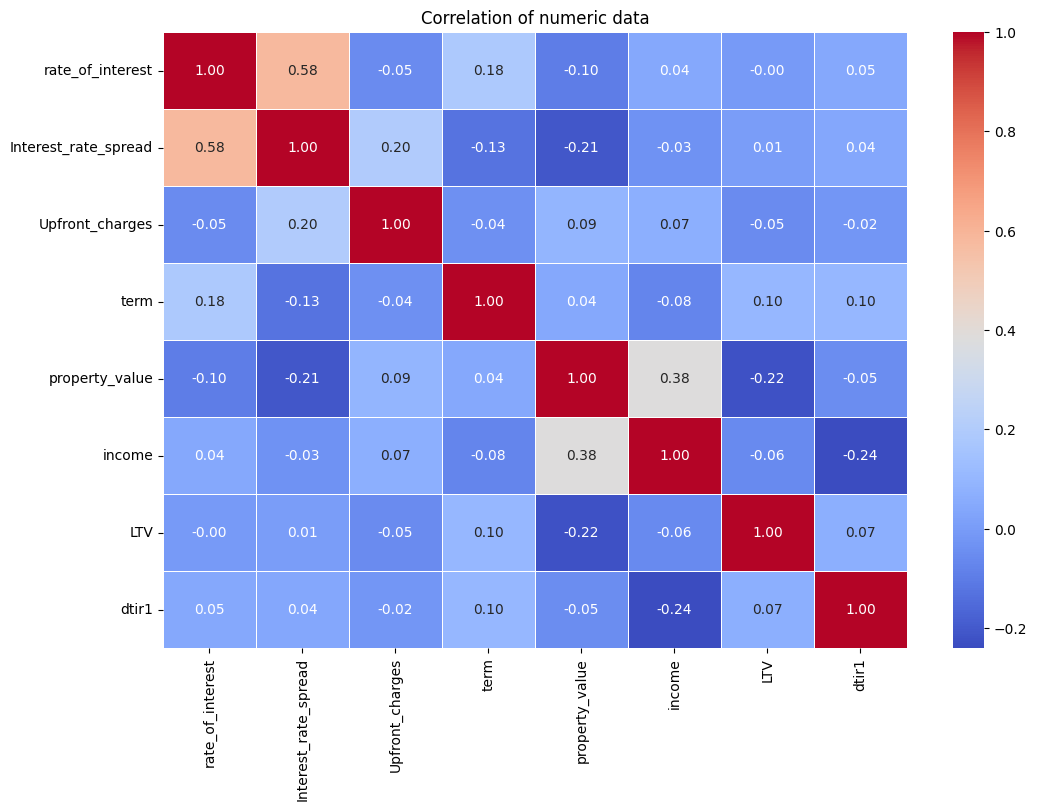

In [11]:
numeric_data=data.select_dtypes(include=['int32','float64'])
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation of numeric data")
plt.show()

I want to add a few more numeric features because almost all of my dataset consists of categorical data.

In [12]:
data['Debt_to_Income'] = data['loan_amount'] / (data['income'] + 1)
data['Has_Security'] = (data['Secured_by'] != 'None').astype(int)
data['Monthly_Payment'] = data['loan_amount'] / (data['term'] + 1)

Let's see the distribution of our numeric data

In [13]:
numeric_data = data.select_dtypes(include=['int32','float64']).columns
num_columns = 3
num_rows = int(np.ceil(len(numeric_data ) / num_columns))

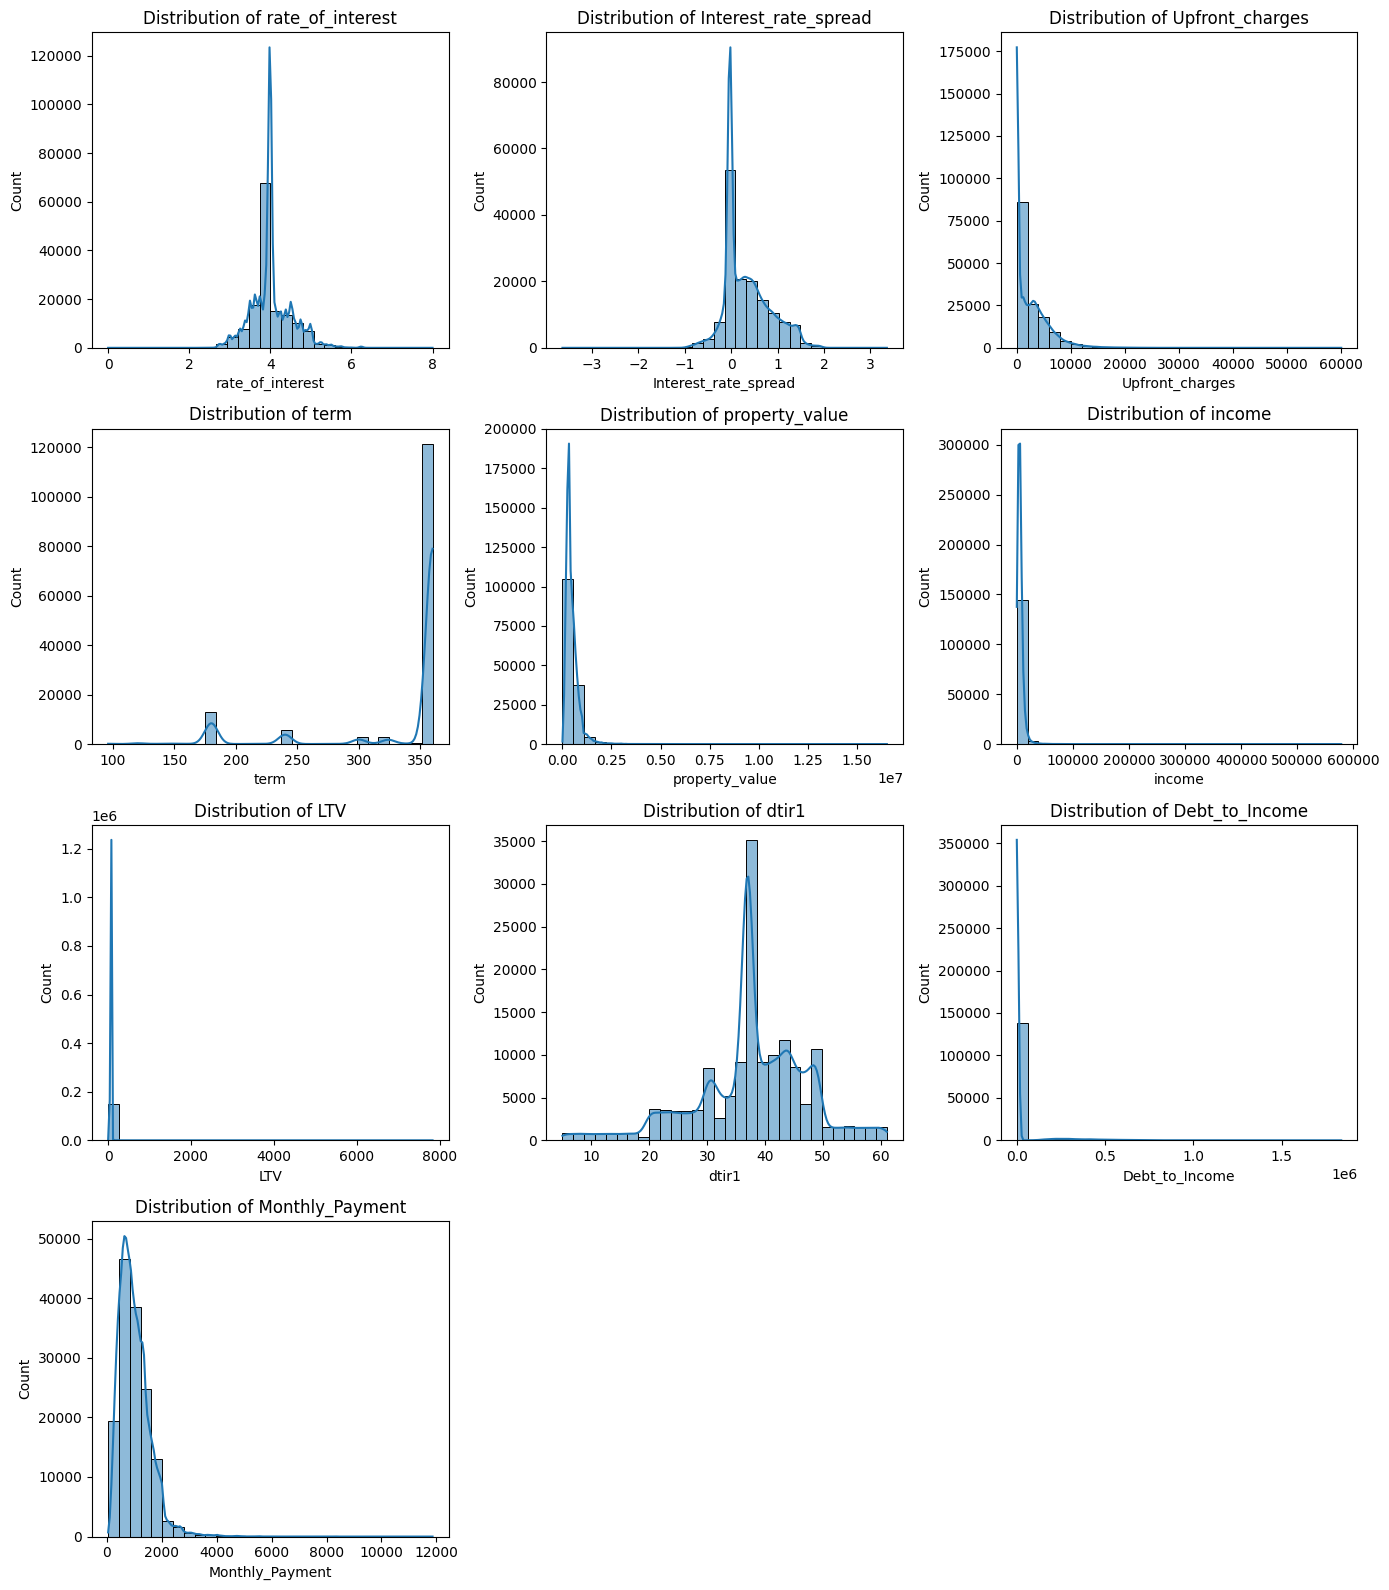

In [14]:
plt.figure(figsize=(14, num_rows * 4))
for i, col in enumerate(numeric_data, 1):
    plt.subplot(num_rows, num_columns, i)
    sns.histplot(data[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

Let's standardize our numeric data. We will also make a copy of our dataset to store the modified data used for training our model

In [15]:
from sklearn.preprocessing import StandardScaler

In [16]:
mod_df=data.copy()

In [17]:
numeric_features = mod_df.select_dtypes(include=['int64', 'float64']).columns
scaler = StandardScaler()
mod_df[numeric_features] = scaler.fit_transform(mod_df[numeric_features])

There, I want to determine whether I should use only One-Hot Encoding or also apply Ordinal Encoding.

In [18]:
uniq_dict={}
for col in object_data:
  print(f'{col}--->{data[col].unique()}')

loan_limit--->['cf' 'ncf']
Gender--->['Sex Not Available' 'Male' 'Joint' 'Female']
approv_in_adv--->['nopre' 'pre']
loan_type--->['type1' 'type2' 'type3']
loan_purpose--->['p1' 'p4' 'p3' 'p2']
Credit_Worthiness--->['l1' 'l2']
open_credit--->['nopc' 'opc']
business_or_commercial--->['nob/c' 'b/c']
Neg_ammortization--->['not_neg' 'neg_amm']
interest_only--->['not_int' 'int_only']
lump_sum_payment--->['not_lpsm' 'lpsm']
construction_type--->['sb' 'mh']
occupancy_type--->['pr' 'sr' 'ir']
Secured_by--->['home' 'land']
total_units--->['1U' '2U' '3U' '4U']
credit_type--->['EXP' 'EQUI' 'CRIF' 'CIB']
co-applicant_credit_type--->['CIB' 'EXP']
age--->['25-34' '55-64' '35-44' '45-54' '65-74' '>74' '<25']
submission_of_application--->['to_inst' 'not_inst']
Region--->['south' 'North' 'central' 'North-East']
Security_Type--->['direct' 'Indriect']


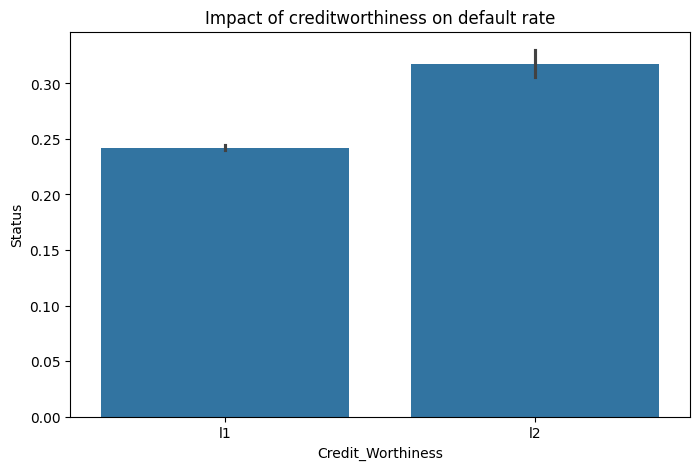

In [19]:
plt.figure(figsize=(8, 5))
sns.barplot(x=data['Credit_Worthiness'], y=data['Status'])
plt.title("Impact of creditworthiness on default rate")
plt.show()

Implement encoding for our object data.

In [20]:
from sklearn.preprocessing import OrdinalEncoder

In [21]:
encoder = OrdinalEncoder(categories=[['l1', 'l2']])
mod_df[['Credit_Worthiness']] = encoder.fit_transform(mod_df[['Credit_Worthiness']])

In [22]:
categorical_features = mod_df.select_dtypes(include=['object']).columns
categorical_features = categorical_features[categorical_features != 'Credit_Worthiness']
mod_df = pd.get_dummies(mod_df, columns=categorical_features, drop_first=True).astype(int)

Let's create our baseline model.

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report


We have an imbalance in the target classes, so we use class_weight to show the model that the class with fewer examples is also important.

In [55]:
from sklearn.utils.class_weight import compute_sample_weight


In [56]:
X = mod_df.drop(columns=['Status'])
y = data['Status']

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y,test_size=0.2, random_state=42)
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)


In [59]:
gb.fit(X_train, y_train,sample_weight=sample_weights)

GradientBoostingClassifier(random_state=42)

In [60]:
y_pred = gb.predict(X_test)

Our baselin's metrics

In [61]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8425954043931572
F1-score: 0.7420228944312337
Precision: 0.6206290471785384
Recall: 0.9224529080159494

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.82      0.89     22364
           1       0.62      0.92      0.74      7273

    accuracy                           0.84     29637
   macro avg       0.80      0.87      0.81     29637
weighted avg       0.88      0.84      0.85     29637



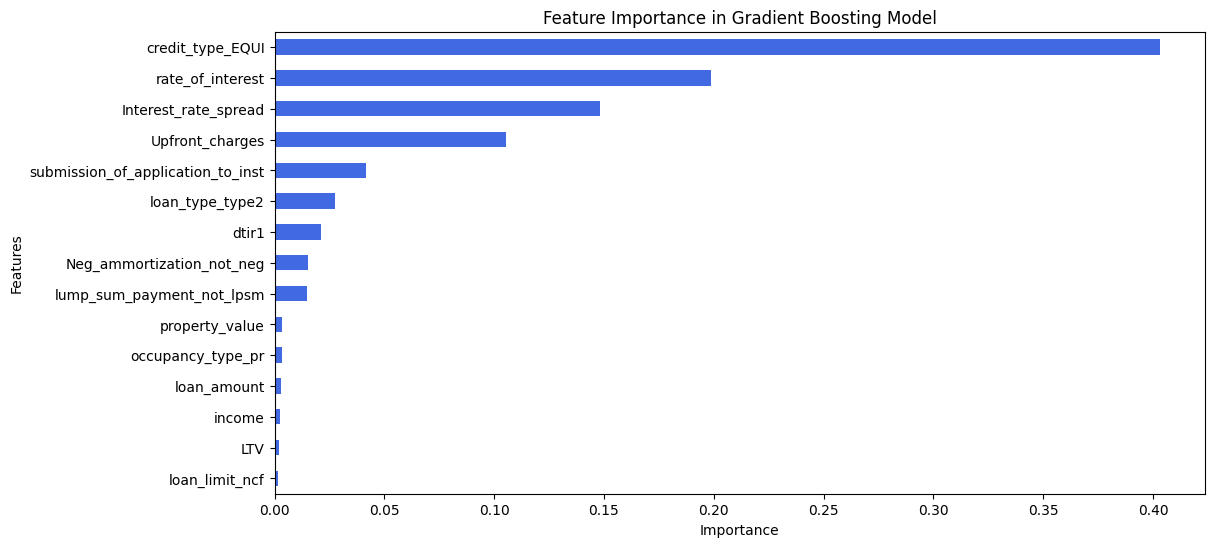

In [62]:
feature_importances = pd.Series(gb.feature_importances_, index=X.columns)
plt.figure(figsize=(12, 6))
feature_importances.nlargest(15).plot(kind='barh', color='royalblue')
plt.title("Feature Importance in Gradient Boosting Model")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.gca().invert_yaxis()
plt.show()

We are trying to find the best hyperparameters to improve our model.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint


In [ ]:
param_dist = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 3, 5],
    'subsample': [0.7, 0.85, 1.0],
    'max_features': ['sqrt', 'log2', None]
}

In [ ]:

gb = GradientBoostingClassifier(random_state=42)
random_search = RandomizedSearchCV(
    gb, param_distributions=param_dist, n_iter=50,
    cv=5, scoring='f1', n_jobs=-1, verbose=2, random_state=42
)

In [ ]:
random_search.fit(X_train, y_train, sample_weight=sample_weights)
print("The best parameters:", random_search.best_params_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
The best parameters: {'subsample': 0.7, 'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': None, 'max_depth': 7, 'learning_rate': 0.1}


We have identified the best hyperparameters for our baseline model. Now, let's use them to build a strong model

In [66]:
best_model = GradientBoostingClassifier(
    subsample=0.7,
    n_estimators=300,
    min_samples_split=5,
    min_samples_leaf= 3,
    max_features=None,
    max_depth=7,
    learning_rate=0.1
)
best_model.fit(X_train, y_train)

GradientBoostingClassifier(max_depth=7, min_samples_leaf=3, min_samples_split=5,
                           n_estimators=300, subsample=0.7)

In [67]:
y_pred = best_model.predict(X_test)

Let's evaluate the metrics of our final model.

In [68]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9092350777744036
F1-score: 0.7997021593447505
Precision: 0.8721780087705051
Recall: 0.738347311975801

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.96      0.94     22364
           1       0.87      0.74      0.80      7273

    accuracy                           0.91     29637
   macro avg       0.90      0.85      0.87     29637
weighted avg       0.91      0.91      0.91     29637



In [69]:
from sklearn.metrics import roc_auc_score, roc_curve, auc

In [71]:
y_prob = gb.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)
print(f'AUC-ROC: {roc_auc:.4f}')

AUC-ROC: 0.9588


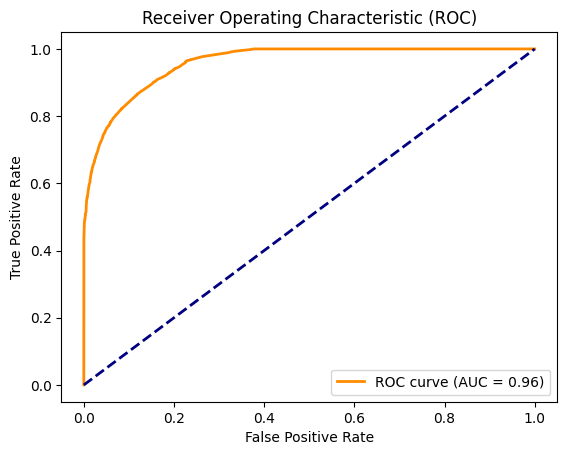

In [72]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc_plot = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_plot:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()

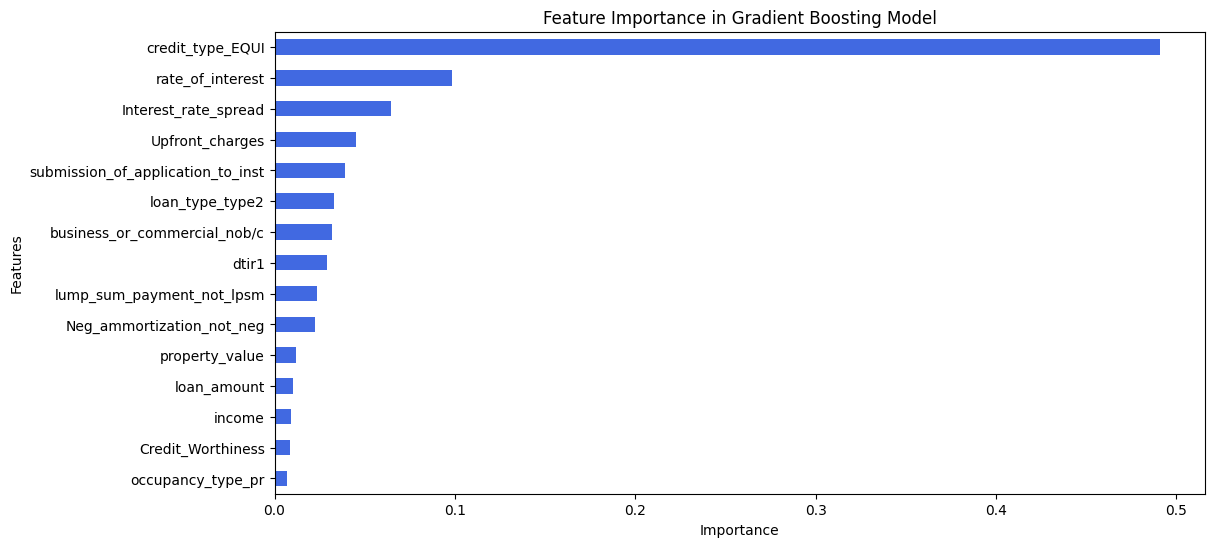

In [73]:
feature_importances = pd.Series(best_model.feature_importances_, index=X.columns)
plt.figure(figsize=(12, 6))
feature_importances.nlargest(15).plot(kind='barh', color='royalblue')
plt.title("Feature Importance in Gradient Boosting Model")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.gca().invert_yaxis()
plt.show()

In [74]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [75]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracy = cross_val_score(best_model, X, y, cv=cv, scoring='accuracy')
precision = cross_val_score(best_model, X, y, cv=cv, scoring='precision')
recall = cross_val_score(best_model, X, y, cv=cv, scoring='recall')
f1 = cross_val_score(best_model, X, y, cv=cv, scoring='f1')


print(f"Cross-Validation Accuracy: {accuracy.mean():.4f} ± {accuracy.std():.4f}")
print(f"Cross-Validation Precision: {precision.mean():.4f} ± {precision.std():.4f}")
print(f"Cross-Validation Recall: {recall.mean():.4f} ± {recall.std():.4f}")
print(f"Cross-Validation F1-score: {f1.mean():.4f} ± {f1.std():.4f}")


KeyboardInterrupt

